# Cell type annotation from marker genes

In single-cell, we have no prior information of which cell type each cell belongs.
To assign cell type labels, we first project all cells in a shared embedded space, 
then we find communities of cells that show a similar transcription profile and finally
we check what cell type specific markers are expressed. If more than one marker
gene is available, statistical methods can be used to test if a set of markers is
enriched in a given cell population.

In this notebook we showcase how to use `decoupler` for cell type annotation with the 3k PBMCs 10X data-set. The data consists of 3k PBMCs from a Healthy Donor and is freely available
from 10x Genomics [here](http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz)
from this [webpage](https://support.10xgenomics.com/single-cell-gene-expression/datasets/1.1.0/pbmc3k)

<div class="alert alert-info">

**Note**
    
This tutorial assumes that you already know the basics of `decoupler`. Else, check out the [Usage](https://decoupler-py.readthedocs.io/en/latest/notebooks/usage.html) tutorial first.

</div>

## Loading packages

First, we need to load the relevant packages, `scanpy` to handle scRNA-seq data
and `decoupler` to use statistical methods.

In [64]:
import scanpy as sc
import decoupler as dc
import numpy as np

# Plotting options, change to your liking
sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))

test_palette = sns.blend_palette(["white",'#f6b48f', '#f37651', '#e13342', '#ad1759', '#701f57', '#35193e'], as_cmap=True)

## Single-cell processing

### Loading the data-set

We can download the data easily using `scanpy`:

In [3]:
adata = sc.read_h5ad('../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

### QC, projection and clustering


Here we follow the standard pre-processing steps as described in the [scanpy vignette](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html).
These steps carry out the selection and filtration of cells based on 
quality control metrics and the data normalization.

<div class="alert alert-info">

**Note**
    
This is just an example, these steps should change depending on the data.

</div> 

In [3]:
# Basic filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')  
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter cells following standard QC criteria.
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

# Normalize the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

Then we group cells based on the similarity of their transcription profiles. 
To visualize the communities we perform UMAP reduction.

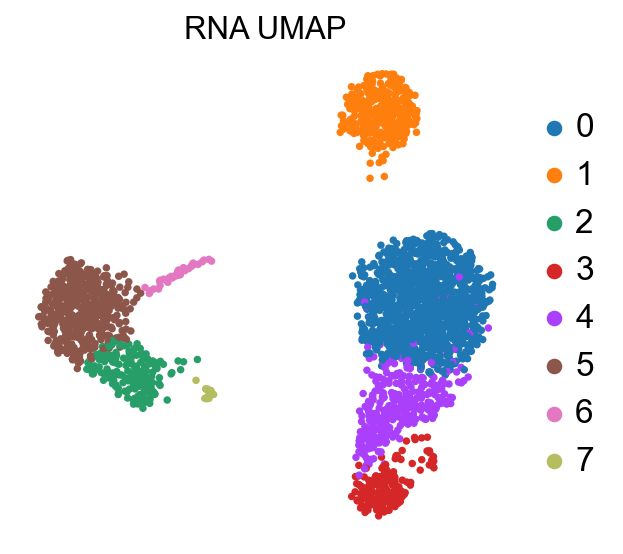

In [4]:
# Identify the highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Regress and scale the data
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

# Generate PCA features
sc.tl.pca(adata, svd_solver='arpack')

# Restore X to be norm counts
dc.swap_layer(adata, 'log_norm', X_layer_key=None, inplace=True)

# Compute distances in the PCA space, and find cell neighbors
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Generate UMAP features
sc.tl.umap(adata)

# Run leiden clustering algorithm
sc.tl.leiden(adata, flavor='igraph', n_iterations=2, directed=False)

# Visualize
sc.pl.umap(adata, color='leiden', title='RNA UMAP', 
           frameon=False, legend_fontweight='normal', legend_fontsize=15)

At this stage, we have identified communities of cells that show a similar 
transcriptomic profile, and we would like to know to which cell type they 
probably belong.

## Marker genes

To annotate single cell clusters, we can use cell type specific marker genes. 
These are genes that are mainly expressed exclusively by a specific cell type, 
making them useful to distinguish heterogeneous groups of cells. Marker genes were
discovered and annotated in previous studies and there are some resources that
collect and curate them.

[Omnipath](https://omnipathdb.org/) is one of the largest available databases of 
curated prior knowledge. Among its resources, there is 
[PanglaoDB](https://panglaodb.se/), a database of cell type markers, 
which can be easily accessed using a wrapper to Omnipath from `decoupler`. 

In [40]:
# Query Omnipath and get PanglaoDB
markers = dc.get_resource(
    name='PanglaoDB',
    organism='mouse',
    license='academic'
)
markers

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,genesymbol,_entity_type,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
0,A1cf,protein,False,Hepatocytes,Endoderm,True,0.189189,0.0044374,True,0.175,0.000257317,9606,Liver,0.002
1,A4galt,protein,True,Mast cells,Mesoderm,True,0.0,0.0141332,True,0.0,0.00302309,9606,Immune system,0.005
2,Aak1,protein,False,Neurons,Ectoderm,True,0.555556,0.0320452,True,0.470588,0.0213838,9606,Brain,0.044
3,Aak1,protein,False,Interneurons,Ectoderm,True,0.0,0.0335213,True,0.529412,0.0414989,9606,Brain,0.044
4,Aanat,protein,True,Astrocytes,Ectoderm,True,0.0,0.0,True,0.0,0.0,9606,Brain,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7417,Zfp503,protein,True,Gamma (PP) cells,Endoderm,True,0.0,0.0298273,False,0.0,0.0,9606,Pancreas,0.006
7418,Zfp521,protein,False,Adipocyte progenitor cells,Mesoderm,True,0.0,0.0103383,False,0.0,0.0,9606,Connective tissue,0.002
7419,Znrf4,protein,False,Germ cells,Mesoderm,True,0.28436,0.0,True,0.0,0.0,9606,Reproductive,0.01
7420,Zpbp2,protein,True,Germ cells,Mesoderm,True,0.436019,0.0,True,0.0,0.0,9606,Reproductive,0.008


In [41]:
markers['canonical_marker'].value_counts()

canonical_marker
True     4868
False    2554
Name: count, dtype: Int64

In [42]:
markers['mouse'].value_counts()

mouse
True     7262
False     160
Name: count, dtype: Int64

In [43]:
markers['mouse_sensitivity'].astype('float')

0       0.175000
1       0.000000
2       0.470588
3       0.529412
4       0.000000
          ...   
7417    0.000000
7418    0.000000
7419    0.000000
7420    0.000000
7421    0.000000
Name: mouse_sensitivity, Length: 7422, dtype: float64

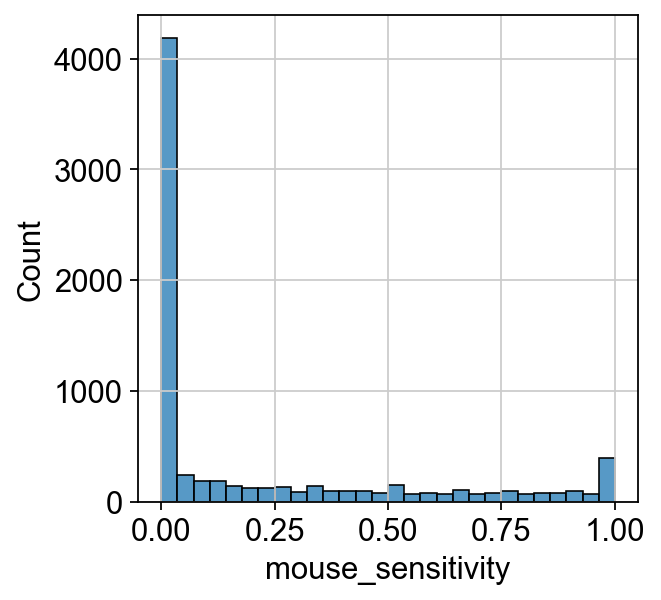

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x = markers['mouse_sensitivity'].astype('float'))
plt.show()

In [45]:
sum(markers['mouse_sensitivity'].astype('float') > 0.5)

1396

Since our data-set is from human cells, and we want best quality of the markers, we can filter by `canonical_marker` and `human`:

In [46]:
# Filter by canonical_marker and human
markers = markers[markers['mouse'].astype(bool) & markers['canonical_marker'].astype(bool) & (markers['mouse_sensitivity'].astype(float) > 0.5)]

# Remove duplicated entries
markers = markers[~markers.duplicated(['cell_type', 'genesymbol'])]
markers

,genesymbol,_entity_type,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
3,Aak1,protein,False,Interneurons,Ectoderm,True,0.0,0.0335213,True,0.529412,0.0414989,9606,Brain,0.044
6,Aard,protein,True,Sertoli cells,Mesoderm,True,0.0,0.0137845,True,1.0,0.0103557,9606,Reproductive,0.012
24,Abcc9,protein,True,Pericytes,Mesoderm,True,0.285714,0.000627943,True,0.818182,0.00736492,9606,Vasculature,0.016
32,Abhd16a,protein,False,Olfactory epithelial cells,Ectoderm,True,0.0,0.0,True,0.566667,0.047316,9606,Olfactory system,0.039
37,Ablim3,protein,False,Retinal ganglion cells,Ectoderm,True,0.0,0.00156691,True,0.869565,0.00386125,9606,Brain,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5492,Pxdc1,protein,True,Pulmonary alveolar type I cells,Endoderm,True,0.0,0.0018797,True,0.823529,0.0326667,9606,Lungs,0.028
5500,Pygm,protein,False,Myocytes,Mesoderm,True,0.0,0.000313283,True,0.777778,0.00243965,9606,Skeletal muscle,0.002
5502,Pyy,protein,True,Alpha cells,Endoderm,True,0.0,0.00126542,True,0.925,0.0179479,9606,Pancreas,0.016
5503,Pyy,protein,True,Enteroendocrine cells,Endoderm,True,0.0,0.00126064,True,0.939394,0.0183256,9606,GI tract,0.016


In [37]:
# Remove duplicated entries
markers = markers[~markers.duplicated(['cell_type', 'germ_layer'])]
markers['germ_layer'].unique()

<StringArray>
['Ectoderm', 'Mesoderm', 'Endoderm', <NA>, 'Epiblast', 'Trophoblast']
Length: 6, dtype: string

For this example we will use these markers, but any collection of genes could be used. To see the list of available resources inside `Omnipath`, run `dc.show_resources()`

## Enrichment with Over Representation Analysis (ORA)

To infer functional enrichment scores we will run the Over Representation Analysis (`ora`) method.
As input data it accepts an expression matrix (`decoupler.run_ora`) or the results of differential expression analysis (`decoupler.get_ora_df`).
For the former, by default the top 5% of expressed genes by sample are selected as the set of interest (S*), and for the latter a user-defined
significance filtering can be used.
Once we have S*, it builds a contingency table using set operations for each set stored in the gene set resource being used (`net`).
Using the contingency table, `ora` performs a one-sided Fisher exact test to test for significance of overlap between sets.
The final score is obtained by log-transforming the obtained p-values, meaning that higher values are more significant.

<img src="../ora.png" />
     
We can run `ora` with a simple one-liner:

In [47]:
dc.run_ora(
    mat=adata,
    net=markers,
    source='cell_type',
    target='genesymbol',
    min_n=3,
    verbose=True,
    use_raw=False
)

Running ora on mat with 38117 samples and 27384 targets for 105 sources.


  0%|          | 0/38117 [00:00<?, ?it/s]

The obtained scores (-log10(p-value))(`ora_estimate`) and p-values (`ora_pvals`) are stored in the `.obsm` key:

In [48]:
adata.obsm['ora_estimate'].head(2)

source,Acinar cells,Adipocytes,Airway goblet cells,Alpha cells,Alveolar macrophages,Anterior pituitary gland cells,Astrocytes,B cells,Basal cells,Basophils,...,Satellite cells,Schwann cells,Sertoli cells,Smooth muscle cells,T cells,T memory cells,Tanycytes,Trigeminal neurons,Tuft cells,Vascular smooth muscle cells
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.0,0.486054,0.293935,0.395394,0.200785,...,-0.00000,0.326007,0.200785,-0.0,0.326007,-0.0,0.717257,0.251298,-0.0,-0.0
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,-0.0,-0.0,-0.0,-0.0,0.326007,-0.0,-0.000000,-0.000000,-0.000000,-0.000000,...,0.60708,-0.000000,-0.000000,-0.0,-0.000000,-0.0,0.717257,0.069061,-0.0,-0.0


## Visualization

To visualize the obtained scores, we can re-use many of `scanpy`'s plotting functions.
First though, we need to extract them from the `adata` object.

In [49]:
acts = dc.get_acts(adata, obsm_key='ora_estimate')

# We need to remove inf and set them to the maximum value observed for pvals=0
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

acts

AnnData object with n_obs × n_vars = 38117 × 105
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_params'
    obsm: 'X_pca', 'X_umap', 'ora_estimate', 'ora_pvals'

In [50]:
acts.var

""
source
Acinar cells
Adipocytes
Airway goblet cells
Alpha cells
Alveolar macrophages
...
T memory cells
Tanycytes
Trigeminal neurons


`dc.get_acts` returns a new `AnnData` object which holds the obtained activities in its `.X` attribute, allowing us to re-use many `scanpy` functions, for example:

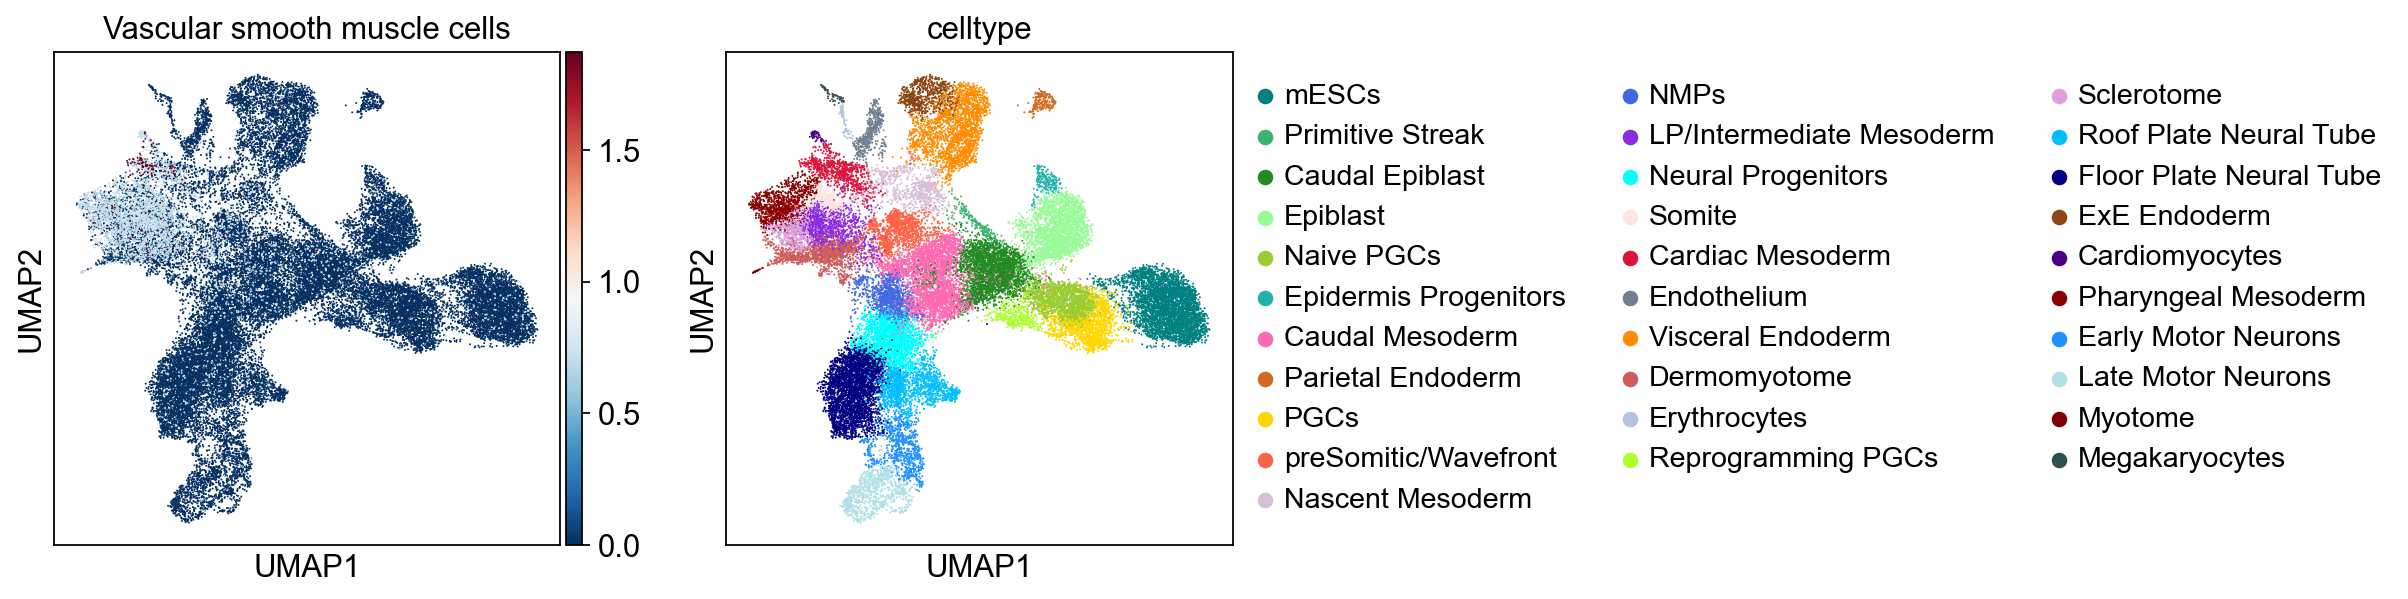

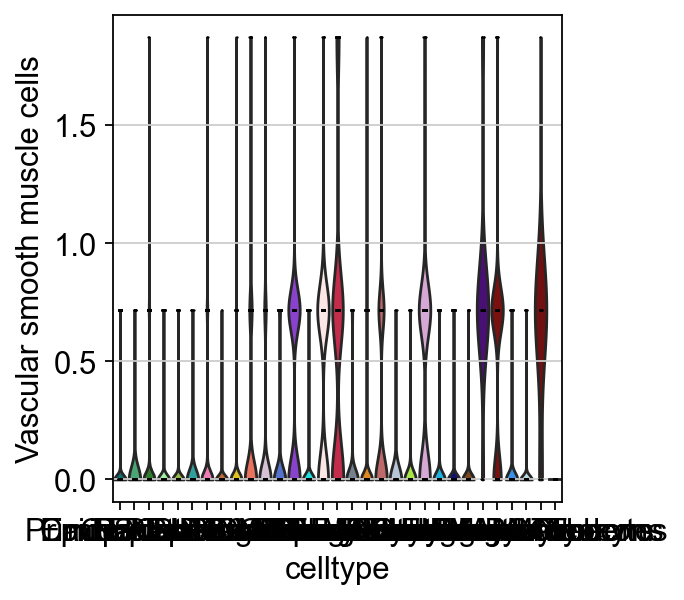

In [53]:
ct = 'Vascular smooth muscle cells'
sc.pl.umap(acts, color=[ct, 'celltype'], cmap='RdBu_r')
sc.pl.violin(acts, keys=[ct], groupby='celltype')

The cells highlighted seem to be enriched by NK cell marker genes.

## Annotation

With `decoupler` we can also identify which are the top predicted cell types per cluster using the 
function `dc.rank_sources_groups`. Here, it identifies "marker" cell types per cluster using
same statistical tests available in scanpy's `scanpy.tl.rank_genes_groups`.

In [58]:
df = dc.rank_sources_groups(acts, groupby='celltype', reference='Caudal Epiblast', method='t-test_overestim_var')
df

,group,reference,names,statistic,meanchange,pvals,pvals_adj
0,Cardiac Mesoderm,Caudal Epiblast,Fibroblasts,31.544752,1.833178,4.010907e-143,4.211452e-141
1,Cardiac Mesoderm,Caudal Epiblast,Pericytes,25.277298,0.679001,3.610202e-107,1.895356e-105
2,Cardiac Mesoderm,Caudal Epiblast,Endothelial cells,24.624447,0.700286,1.818630e-100,6.365206e-99
3,Cardiac Mesoderm,Caudal Epiblast,Pancreatic stellate cells,24.008881,1.099261,2.156921e-96,5.661917e-95
4,Cardiac Mesoderm,Caudal Epiblast,Sertoli cells,23.302906,0.353123,6.356593e-96,1.334884e-94
...,...,...,...,...,...,...,...
3145,preSomitic/Wavefront,Caudal Epiblast,Trigeminal neurons,-14.001053,-0.177620,1.665619e-42,1.589909e-41
3146,preSomitic/Wavefront,Caudal Epiblast,Luminal epithelial cells,-14.710592,-0.177088,9.159099e-47,1.068562e-45
3147,preSomitic/Wavefront,Caudal Epiblast,Cholangiocytes,-14.851041,-0.113009,2.297445e-47,3.015397e-46
3148,preSomitic/Wavefront,Caudal Epiblast,Mammary epithelial cells,-20.887592,-0.165232,2.082043e-87,7.287151e-86


We can then extract the top 3 predicted cell types per cluster:

In [59]:
n_ctypes = 3
ctypes_dict = df.groupby('group').head(n_ctypes).groupby('group')['names'].apply(lambda x: list(x)).to_dict()
ctypes_dict

{'Cardiac Mesoderm': ['Fibroblasts', 'Pericytes', 'Endothelial cells'],
 'Cardiomyocytes': ['Myoblasts', 'Smooth muscle cells', 'Cardiomyocytes'],
 'Caudal Mesoderm': ['Nuocytes', 'Neural stem/precursor cells', 'Neuroblasts'],
 'Dermomyotome': ['Kidney progenitor cells', 'Chondrocytes', 'Pericytes'],
 'Early Motor Neurons': ['Neuroblasts',
  'Bergmann glia',
  'Photoreceptor cells'],
 'Endothelium': ['Endothelial cells',
  'Endothelial cells (aorta)',
  'Intercalated cells'],
 'Epiblast': ['Satellite cells', 'Myoblasts', 'Enteric neurons'],
 'Epidermis Progenitors': ['Myofibroblasts', 'Pericytes', 'Basal cells'],
 'Erythrocytes': ['Erythroid-like and erythroid precursor cells',
  'Platelets',
  'Hematopoietic stem cells'],
 'ExE Endoderm': ['Podocytes',
  'Choroid plexus cells',
  'Mammary epithelial cells'],
 'Floor Plate Neural Tube': ['Retinal progenitor cells',
  'Radial glia cells',
  'Neural stem/precursor cells'],
 'LP/Intermediate Mesoderm': ['Vascular smooth muscle cells',
  '

We can visualize the obtained top predicted cell types:

categories: Ectoderm, Endoderm, Mesoderm, etc.
var_group_labels: Cardiac Mesoderm, Cardiomyocytes, Caudal Mesoderm, etc.


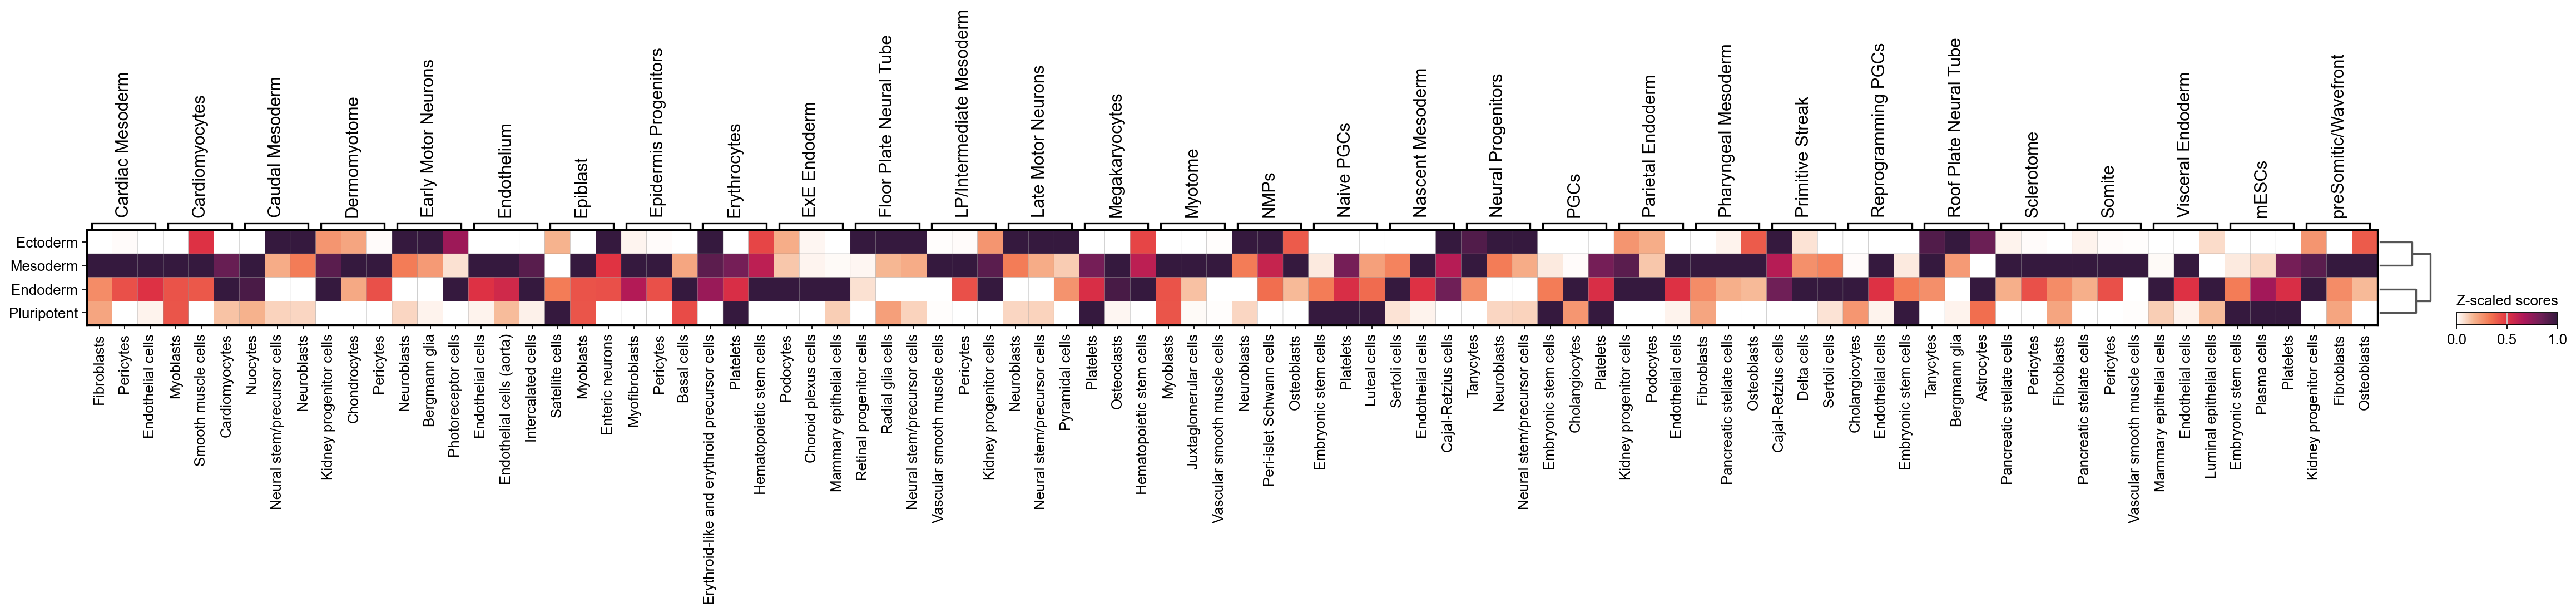

In [65]:
sc.pl.matrixplot(acts, ctypes_dict, 'lineage', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap=test_palette)

From this plot we see that cluster 7 belongs to Platelets, cluster 4 appear to be NK cells, custers 0 and 3 might be T-cells, cluster 2 should be some sort of B cells and that clusters 6,5 and 1 belong to the myeloid lineage.

We can check individual cell types by plotting their distributions:

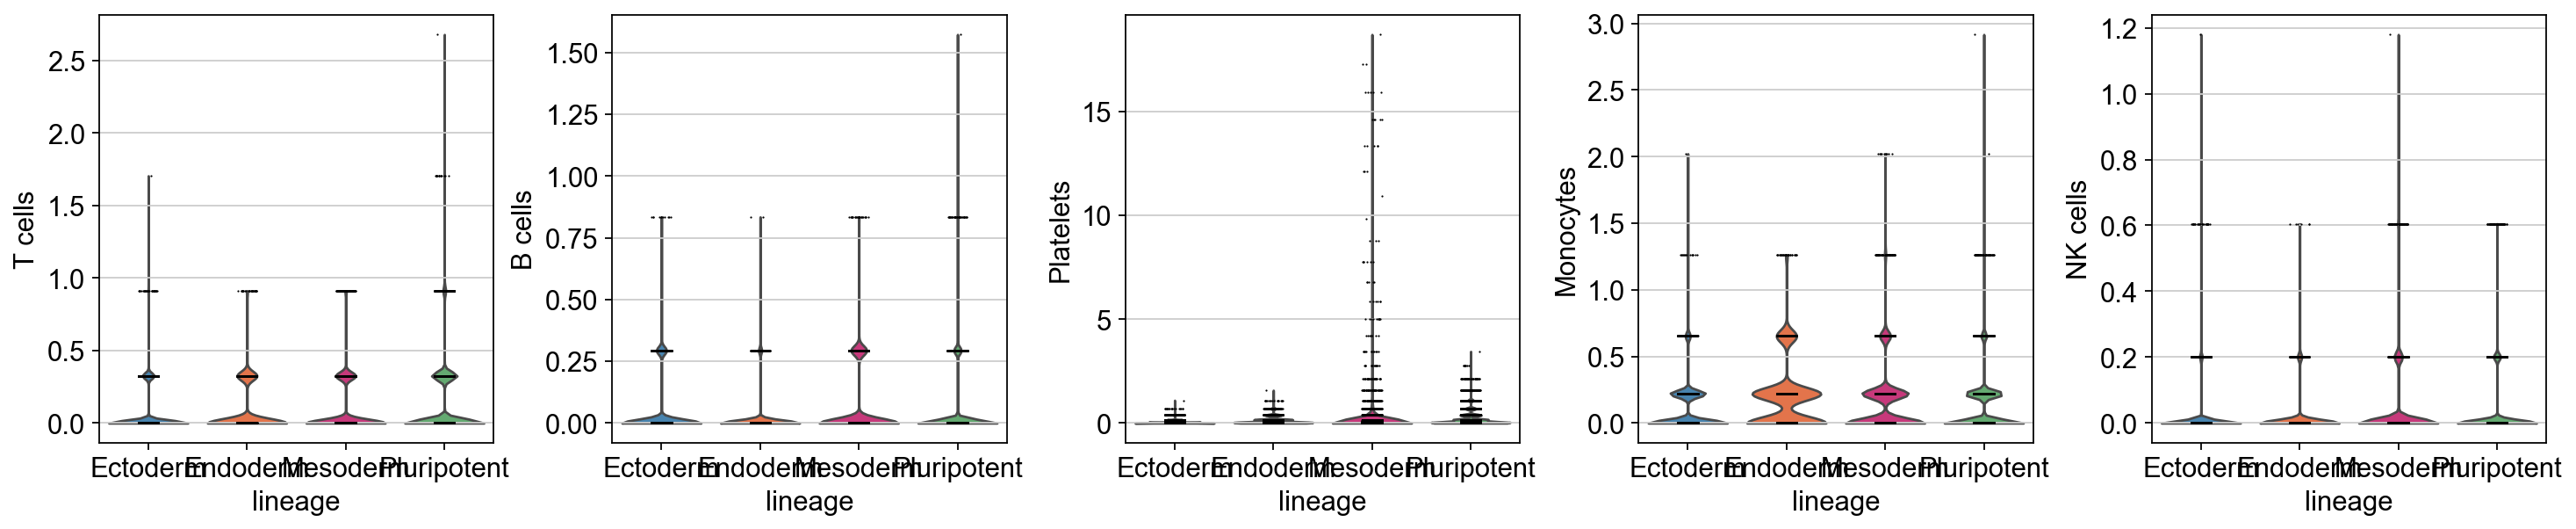

In [66]:
sc.pl.violin(acts, keys=['T cells', 'B cells', 'Platelets', 'Monocytes', 'NK cells'], groupby='lineage')

The final annotation should be done manually based on the assessment of the enrichment results. However, an automatic prediction can be made by assigning the top predicted cell type per cluster. This approach does not require expertise in the tissue being studied but **can be prone to errors**. Nonetheless it can be useful to generate a first draft, let's try it:

In [15]:
annotation_dict = df.groupby('group').head(1).set_index('group')['names'].to_dict()
annotation_dict

{'0': 'T memory cells',
 '1': 'B cells naive',
 '2': 'Macrophages',
 '3': 'Gamma delta T cells',
 '4': 'NK cells',
 '5': 'Neutrophils',
 '6': 'Langerhans cells',
 '7': 'Platelets'}

Once we have selected the top cell type we can finally annotate:

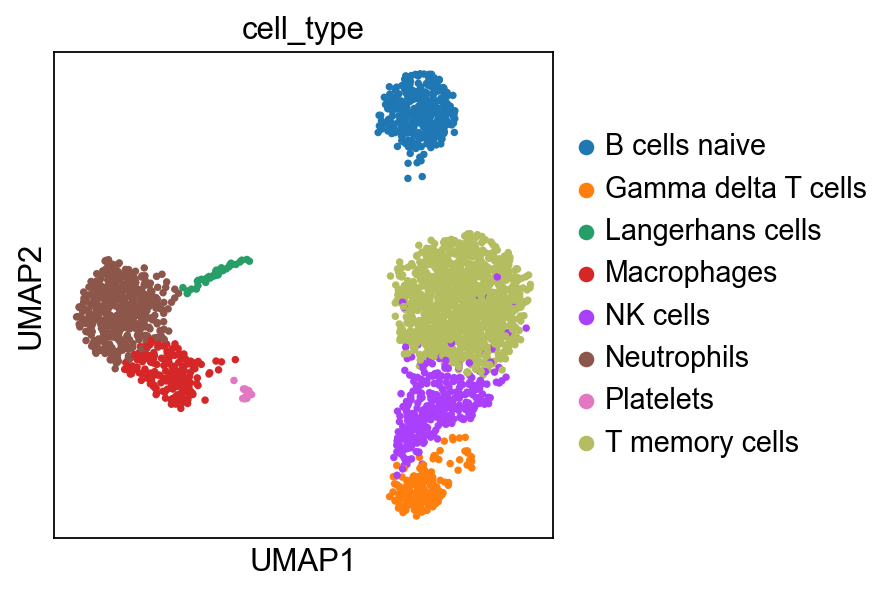

In [16]:
# Add cell type column based on annotation
adata.obs['cell_type'] = [annotation_dict[clust] for clust in adata.obs['leiden']]

# Visualize
sc.pl.umap(adata, color='cell_type')

Compared to the annotation obtained by the `scanpy` tutorial, it is very similar but there are some errors, highlything the limitation of automatic annotation.

<img src="https://scanpy.readthedocs.io/en/stable/_images/66235fc964a35fcf52eb3497082c6feb3d49f0259d6371adb9c4ff0bf06bbb1a.png" width="300" height="300" />

<div class="alert alert-info">

**Note**

Cell annotation should always be revised by an expert in the tissue of interest, this notebook only shows how to generate a first draft of it.

</div> 